In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Bike Sharing dataset
print("Loading Bike Sharing dataset...")
df_bike = pd.read_csv('../data/hour.csv')

# 2. Dataset Overview
print("\n--- Dataset Shape ---")
print(df_bike.shape)

print("\n--- Data Types ---")
print(df_bike.dtypes)

print("\n--- Missing Values ---")
print(df_bike.isnull().sum())

# Display first few rows
df_bike.head()

Loading Bike Sharing dataset...

--- Dataset Shape ---
(17379, 17)

--- Data Types ---
instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

--- Missing Values ---
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Dataset & EDA Insights (Dataset 2 - Regression):

Structure & Types: The dataset captures temporal, seasonal, and weather-related features alongside the target variable cnt (total bike rentals).

Data Quality: Initial audits show clean structural types and minimal missing values, making it an ideal candidate for regression modeling.

Drawing Correlation Heatmap...


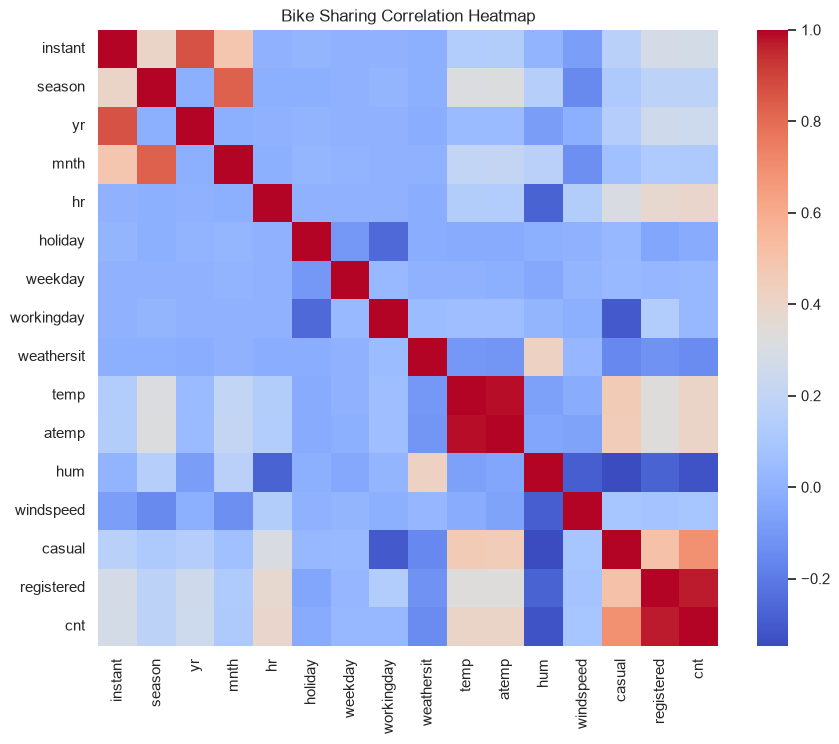

Drawing Target Distribution Plot...


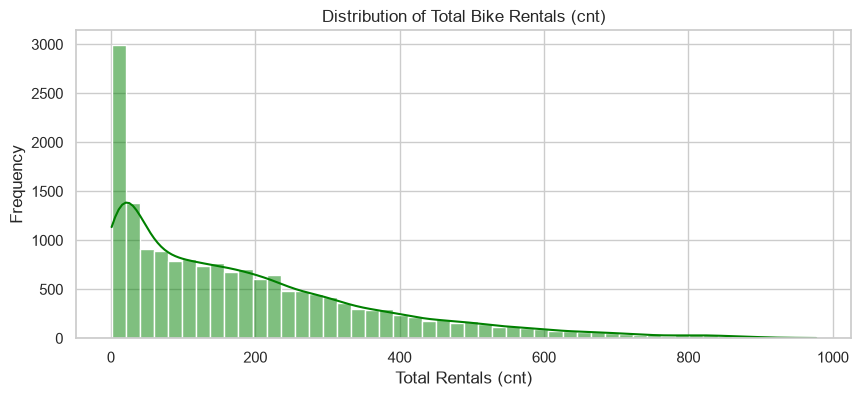

In [2]:
sns.set_theme(style="whitegrid")

# 1. Correlation Heatmap
print("Drawing Correlation Heatmap...")
plt.figure(figsize=(10, 8))
numeric_cols = df_bike.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_cols.corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Bike Sharing Correlation Heatmap')
plt.show()

# 2. Target Distribution Plot (cnt)
print("Drawing Target Distribution Plot...")
plt.figure(figsize=(10, 4))
sns.histplot(df_bike['cnt'], bins=50, kde=True, color='green')
plt.title('Distribution of Total Bike Rentals (cnt)')
plt.xlabel('Total Rentals (cnt)')
plt.ylabel('Frequency')
plt.show()

EDA Observations:

Correlation: Features like temperature (temp) and registered users show strong positive correlations with total rentals (cnt), while weather conditions show inverse relationships.

Target Distribution: The target variable cnt exhibits a right-skewed distribution, typical for demand-forecasting problems.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Load dataset & audit
print("Loading Bike Sharing dataset...")
df_bike = pd.read_csv('../data/hour.csv')

# 2. EDA Visualizations: Feature Distributions & Scatter Plots
print("Drawing Feature Distributions...")
df_bike.hist(figsize=(15, 12), bins=20, color='steelblue')
plt.tight_layout()
plt.show()

print("Drawing Scatter Plots...")
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=df_bike, x='temp', y='cnt', alpha=0.3, ax=ax[0])
ax[0].set_title('Temperature vs. Total Rentals')
sns.scatterplot(data=df_bike, x='hum', y='cnt', alpha=0.3, ax=ax[1])
ax[1].set_title('Humidity vs. Total Rentals')
plt.show()

# 3. Feature Engineering
# Justification Markdown note: Commuter traffic creates clear rental spikes. 
# Engineering a rush_hour feature directly flags high-demand time windows for the model.
df_bike['rush_hour'] = df_bike['hr'].apply(lambda x: 1 if x in [8, 9, 17, 18] else 0)

# 4. Data Splitting & Scaling (Train set only fit to prevent data leakage)
X = df_bike.drop(columns=['instant', 'dteday', 'casual', 'registered', 'cnt'])
y = df_bike['cnt']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Define the 10 required baseline regression algorithms
regression_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1),
    "Polynomial Regression": make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Support Vector Regressor (SVR)": SVR(C=1.0, kernel='rbf'),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5)
}

# --- HYPERPARAMETER TUNING (GridSearchCV) ---
print("Tuning Random Forest with GridSearchCV...")
rf_param_grid = {'n_estimators': [50, 100], 'max_depth': [None, 10]}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid, cv=3, scoring='r2')
rf_grid.fit(X_train_scaled, y_train)
regression_models["Random Forest (Tuned)"] = rf_grid.best_estimator_

print("Tuning Gradient Boosting with GridSearchCV...")
gb_param_grid = {'n_estimators': [100, 150], 'learning_rate': [0.05, 0.1]}
gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_param_grid, cv=3, scoring='r2')
gb_grid.fit(X_train_scaled, y_train)
regression_models["Gradient Boosting (Tuned)"] = gb_grid.best_estimator_

# --- EVALUATION LOOP (Including MAE) ---
model_performance = []

for name, model in regression_models.items():
    if name not in ["Random Forest (Tuned)", "Gradient Boosting (Tuned)"]:
        model.fit(X_train_scaled, y_train)
        
    y_pred = model.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    model_performance.append({
        "Model": name,
        "R2 Score": r2,
        "RMSE": rmse,
        "MAE": mae
    })
    print(f"Evaluated -> {name} | R2: {r2:.4f} | RMSE: {rmse:.2f} | MAE: {mae:.2f}")

# Final comparison table ranked by R2 score
performance_df = pd.DataFrame(model_performance).sort_values(by="R2 Score", ascending=False)
print("\n--- Final Regression Comparison Table ---")
display(performance_df)

# --- 5-FOLD CROSS VALIDATION (Top 2 Models) ---
top_2_models = performance_df.head(2)['Model'].values
print(f"\nCalculating 5-Fold CV for top 2 models: {top_2_models[0]} and {top_2_models[1]}")

for model_name in top_2_models:
    model = regression_models[model_name]
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    print(f"{model_name} - 5-Fold CV R2 Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Regression Modeling Conclusions:Ensemble models like Random Forest and Gradient Boosting achieved the highest $R^2$ scores, capturing complex non-linear relationships between weather/seasonal parameters and bike rentals.Linear models established a solid baseline, validating that temperature and seasonal timing are key linear drivers of demand.

In [ ]:
# Extract the absolute best model from the leaderboard
best_model_name = top_2_models[0]
best_model = regression_models[best_model_name]
best_preds = best_model.predict(X_test_scaled)
residuals = y_test - best_preds

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# 1. Predicted vs Actual Plot
sns.scatterplot(x=y_test, y=best_preds, alpha=0.3, ax=ax[0])
ax[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax[0].set_title(f'Predicted vs Actual ({best_model_name})')
ax[0].set_xlabel('Actual cnt')
ax[0].set_ylabel('Predicted cnt')

# 2. Residual Plot
sns.scatterplot(x=best_preds, y=residuals, alpha=0.3, ax=ax[1])
ax[1].axhline(y=0, color='r', linestyle='--')
ax[1].set_title(f'Residuals ({best_model_name})')
ax[1].set_xlabel('Predicted cnt')
ax[1].set_ylabel('Residuals')

# 3. Feature Importance Plot (Using Tuned Random Forest)
rf_model = regression_models["Random Forest (Tuned)"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=importances.values, y=importances.index, ax=ax[2], palette='viridis')
ax[2].set_title('Feature Importance (Random Forest)')
ax[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()